<a href="https://colab.research.google.com/github/asthakateha912-collab/CodeRepo/blob/main/housePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/housing.csv.zip")

In [ ]:

print(df.shape)
print(list(df.columns))

(20640, 10)
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [ ]:
print("\nMissing values")
print(df.isnull().sum())
print("Target summary")
print(df["median_house_value"].describe())


Missing values
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
Target summary
count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64


In [ ]:
df = df.dropna(subset=["total_bedrooms"])
print(df.shape)

(20433, 10)


In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
x= df.drop(columns=["median_house_value","ocean_proximity"])
y = df["median_house_value"]
print(x.shape)
print(y.shape)

(20433, 8)
(20433,)


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)



(16346, 8)
(4087, 8)


In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [ ]:
model = LinearRegression()
model.fit(x_train,y_train)


LinearRegression()

In [ ]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

In [ ]:
print(y_train_pred[:5])
print("-"*50)
print(y_test_pred[:5])

[245906.31381088 141217.81122484 214449.14583333 169887.7502966
 194069.98461998]
--------------------------------------------------
[197058.03752153 157508.79088918 202099.26270387 173501.82273784
 213795.18417458]


In [ ]:
def print_regression_metrics(title, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(title)
    print(f"  MAE: {mae:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R^2: {r2:.2f}")

In [ ]:
print_regression_metrics("TRAIN METRICS", y_train, y_train_pred)
print_regression_metrics("TEST METRICS", y_test, y_test_pred)

TRAIN METRICS
  MAE: 50629.50
  MSE: 4817977906.77
  RMSE: 69411.66
  R^2: 0.64
TEST METRICS
  MAE: 51372.67
  MSE: 4921881237.63
  RMSE: 70156.12
  R^2: 0.64


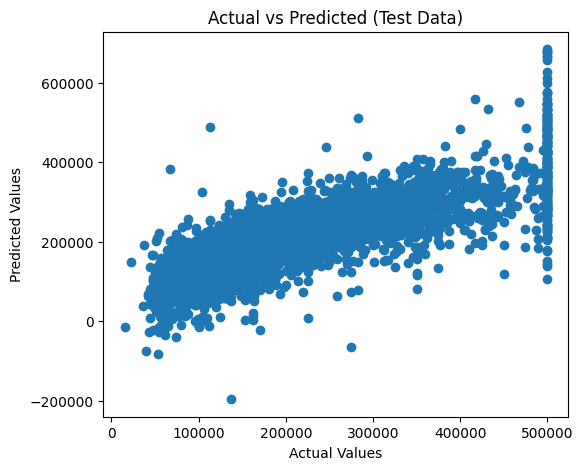

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Test Data)")
plt.show()